# Notebook 09 - Uncertainty Quantification (Second version)

City-agnostic improved workflow for **Athens**. This version keeps the original March 2026 `NB09` untouched and adds three targeted improvements:
- spatially explicit daily raster modifiers for trees and waste heat
- event-level warning-day logic for EWS
- EWS CBA uncertainty outputs alongside the impact uncertainty outputs

All new outputs are written to `outputs_variants/masselot_main/athens/tables/uncertainty_improved_fast/` so the original `NB09` outputs remain unchanged.


In [1]:
import os
os.environ["URBAN_HEAT_OUTPUT_VARIANT"] = "masselot_main"
os.environ["IF_MAIN_FAMILY"] = "masselot_tail"


In [2]:
import os
import sys
from pathlib import Path

os.environ.setdefault('CITY', 'athens')
os.environ.setdefault('NB09_N', '512')
os.environ.setdefault('NB09_SEED', '42')
os.environ.setdefault('NB09_MAKE_FIGURES', '0')
os.environ.setdefault('HAZARD_TRACK', 'standard')

def _find_repo_root():
    env = os.environ.get("URBAN_HEAT_ROOT")
    if env:
        root = Path(env).expanduser().resolve()
        if (root / "cityheat").is_dir() and (root / "configs").is_dir():
            return root
    start = Path.cwd().resolve()
    for cand in [start, *start.parents]:
        if (cand / "cityheat").is_dir() and (cand / "configs").is_dir():
            return cand
    raise RuntimeError(
        "Could not locate repo root. Run the notebook from inside the repo "
        "or set URBAN_HEAT_ROOT."
    )

ROOT = _find_repo_root()
output_variant = os.environ.get('URBAN_HEAT_OUTPUT_VARIANT', '').strip()
if not output_variant:
    raise RuntimeError('Masselot-main NB09 requires URBAN_HEAT_OUTPUT_VARIANT.')
OUTPUT_ROOT = ROOT / 'outputs_variants' / output_variant
os.environ.setdefault('MPLCONFIGDIR', str(OUTPUT_ROOT / '.mpl'))
os.environ.setdefault('XDG_CACHE_HOME', str(OUTPUT_ROOT / '.cache'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
Path(os.environ['XDG_CACHE_HOME']).mkdir(parents=True, exist_ok=True)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('ROOT:', ROOT)
print('CITY:', os.environ['CITY'])
print('NB09_N:', os.environ['NB09_N'])
print('NB09_SEED:', os.environ['NB09_SEED'])


ROOT: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat
CITY: athens
NB09_N: 512
NB09_SEED: 42


In [3]:
import logging, warnings, os
warnings.filterwarnings('ignore', category=FutureWarning)
for _name in ['climada', 'climada.hazard', 'climada.hazard.base', 'SALib']:
    logging.getLogger(_name).setLevel(logging.ERROR)
print('NB09 Masselot-main full run: city=athens, N=512, seed=42, figures enabled')
print('URBAN_HEAT_OUTPUT_VARIANT=', os.environ.get('URBAN_HEAT_OUTPUT_VARIANT'))
print('IF_MAIN_FAMILY=', os.environ.get('IF_MAIN_FAMILY'))

NB09 Masselot-main full run: city=athens, N=512, seed=42, figures enabled
URBAN_HEAT_OUTPUT_VARIANT= masselot_main
IF_MAIN_FAMILY= masselot_tail


In [4]:
from cityheat.nb09_improved_fast_masselot_main import run_nb09_improved_fast

paths = run_nb09_improved_fast()
paths


[NB09 masselot-main] Run type: masselot_headline_lhs_band — Masselot extrapolation-bracketed LHS over ['masselot_tail', 'masselot']; output dir: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/athens/tables/uncertainty_improved_fast


[athens] sample 1/512: year=2050 aai=0.973


[athens] sample 2/512: year=2040 aai=0.989


[athens] sample 3/512: year=2040 aai=0.779


[athens] sample 4/512: year=2020 aai=0.839


...

[athens] sample 512/512: year=2020 aai=0.052


/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:139: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:140: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:141: RuntimeWarning: All-NaN slice encountered
  maxs = np.nanmax(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat

/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:139: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:140: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:141: RuntimeWarning: All-NaN slice encountered
  maxs = np.nanmax(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat

/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:139: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:140: RuntimeWarning: All-NaN slice encountered
  med = np.nanmedian(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:141: RuntimeWarning: All-NaN slice encountered
  maxs = np.nanmax(p_ind)
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/SALib/analyze/pawn.py:138: RuntimeWarning: All-NaN slice encountered
  mins = np.nanmin(p_ind)
/opt/anaconda3/envs/urbanheat

{'headline_unc_dir': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/athens/tables/uncertainty_improved_fast'),
 'headline__samples': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/athens/tables/uncertainty_improved_fast/unc_samples_athens_improved_fast.csv'),
 'samples': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/athens/tables/uncertainty_improved_fast/unc_samples_athens_improved_fast.csv'),
 'headline__impact': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/athens/tables/uncertainty_improved_fast/unc_impact_summary_athens_improved_fast.csv'),
 'impact': PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/athens/tables/uncertainty_improved_fast/unc_impact_summary_athens_improved_fast.csv

In [5]:
import pandas as pd

samples = pd.read_csv(paths['samples'])
samples[[
    'year', 'aai_agg', 'annual_deaths', 'sample_warning_days',
    'sample_threshold_deaths_per_day', 'ews_pv_cost_25y',
    'ews_net_avoided_deaths_25y_cum', 'ews_cost_per_net_death_25y_cum'
]].head(10)

,year,aai_agg,annual_deaths,sample_warning_days,sample_threshold_deaths_per_day,ews_pv_cost_25y,ews_net_avoided_deaths_25y_cum,ews_cost_per_net_death_25y_cum
0,2050,0.973079,355.173742,72.0,2.679105,2.279270e+07,220.297564,103463.235853
1,2040,0.988982,361.967312,50.0,3.902411,4.299284e+06,541.197190,7944.025163
2,2040,0.779453,285.279847,47.0,3.173722,1.968664e+07,283.614385,69413.389608
3,2020,0.839439,307.234702,23.0,4.651589,3.359936e+06,1358.095993,2474.004912
4,2050,0.782369,285.564578,53.0,2.665994,1.881912e+07,114.177015,164824.066288
5,2040,0.424758,155.461353,28.0,2.598456,1.954666e+06,445.376318,4388.797529
6,2050,0.596825,217.840965,60.0,1.883407,3.552529e+06,178.431552,19909.758459
7,2040,0.670140,245.271199,50.0,2.725149,4.402535e+06,782.451845,5626.588671
8,2050,0.975794,356.164741,58.0,3.022214,2.703310e+06,151.068682,17894.578645
9,2020,0.606801,222.089181,30.0,3.108882,3.817974e+06,143.662385,26576.015208


In [6]:
impact_summary = pd.read_csv(paths['impact'])
cba_summary = pd.read_csv(paths['cba'])

display(impact_summary.describe())
display(cba_summary.describe())

,aai_agg,annual_deaths,rp2,rp5,rp10,rp20
count,512.000000,512.000000,5.120000e+02,512.000000,512.000000,512.000000
mean,0.809472,295.845156,6.073533e-05,1.747335,3.632935,4.363154
std,0.233972,85.439772,1.000392e-04,0.681959,0.978637,1.171026
min,0.354059,129.231500,4.129598e-08,0.607092,1.716541,2.044695
25%,0.645238,235.736061,2.961655e-06,1.259454,2.931878,3.516204
50%,0.770377,281.196390,2.107726e-05,1.577590,3.442103,4.137193
75%,0.941394,343.844155,8.028196e-05,2.096602,4.178182,5.033858
max,1.691979,617.572163,1.005930e-03,4.352648,7.220154,8.877390


,ews_pv_cost_25y,ews_net_avoided_deaths_25y_cum,ews_net_avoided_deaths_25y_pv,ews_cost_per_net_death_25y_cum,ews_cost_per_net_death_25y_pv,ews_life_years_saved_25y_cum
count,5.120000e+02,512.000000,512.000000,512.000000,512.000000,512.000000
mean,1.447961e+07,390.725948,247.102169,58671.146811,91541.380266,4851.055843
std,1.173083e+07,301.845976,200.797665,70311.155142,105419.274029,3744.018866
min,1.702400e+06,41.731682,23.475783,2412.362251,3218.284276,501.787786
25%,3.560526e+06,186.629261,112.247120,11888.588961,18783.059748,2302.793850
50%,8.358926e+06,311.785506,182.672949,30865.787911,49266.513923,3774.409158
75%,2.539037e+07,480.509160,307.806166,76875.751778,126623.894008,5942.840501
max,4.015387e+07,1836.429921,1376.551553,410657.376803,570322.541020,23072.577605


## Masselot-main NB09 output paths

- bundle: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/athens/tables/uncertainty_improved_fast/unc_impact_athens_march2026_improved_fast.h5

- bundle_sens: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/athens/tables/uncertainty_improved_fast/unc_impact_athens_march2026_improved_fast_with_sensitivity.h5

- burke_sensitivity_burke_polynomial__bundle: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/athens/tables/uncertainty_burke_sensitivity/burke_polynomial/unc_impact_athens_march2026_improved_fast.h5

- burke_sensitivity_burke_polynomial__bundle_sens: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/athens/tables/uncertainty_burke_sensitivity/burke_polynomial/unc_impact_athens_march2026_improved_fast_with_sensitivity.h5

...

- vuln: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs_variants/masselot_main/athens/tables/uncertainty_improved_fast/unc_vulnerability_athens_improved_fast.csv

## Headline sample IF-family counts

,n
if_family,
masselot,256
masselot_tail,256


## Generated headline NB09 figures

### unc_distribution_aai_agg_athens_improved_fast.png

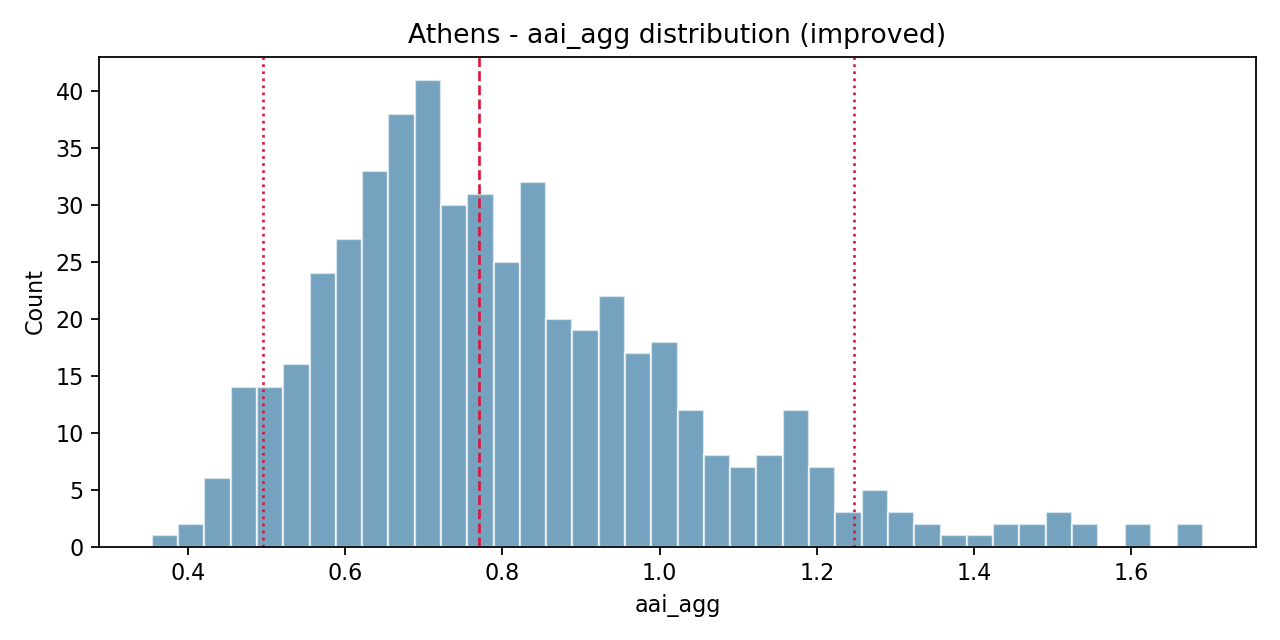

### unc_cdf_aai_agg_athens_improved_fast.png

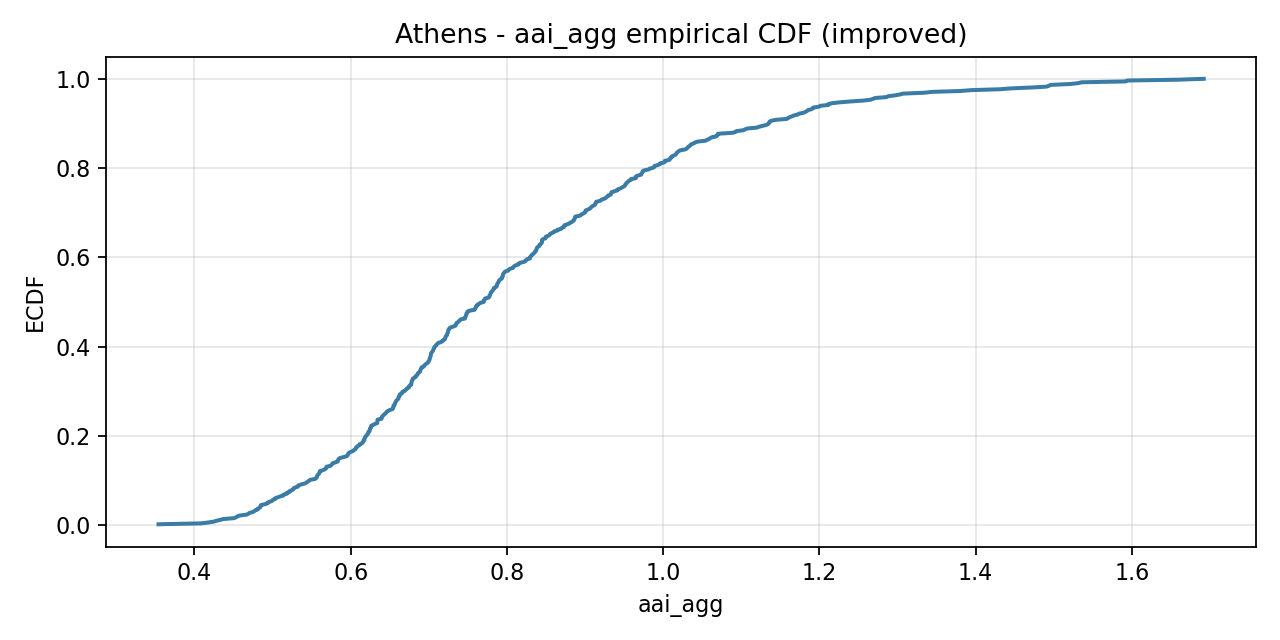

### sens_tornado_aai_agg_athens_improved_fast.png

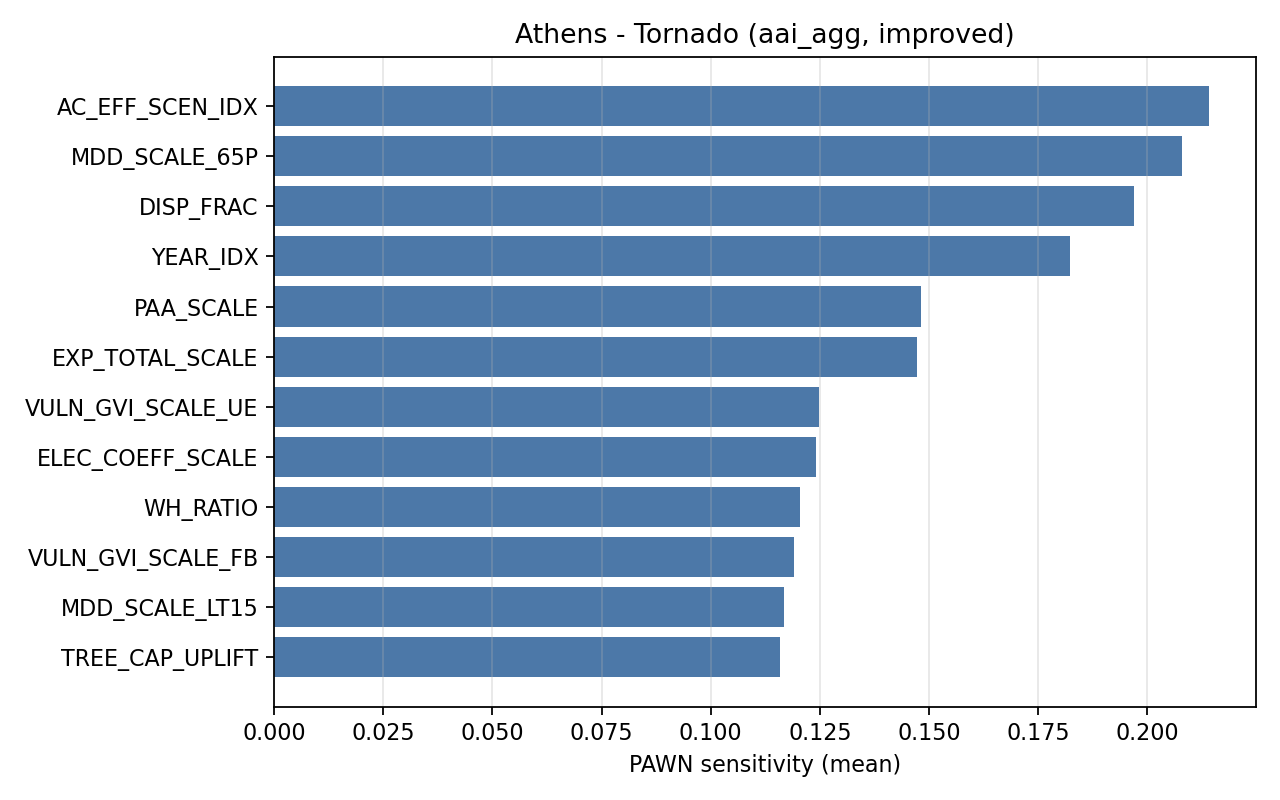

### unc_distribution_cba_ews_athens_improved_fast.png

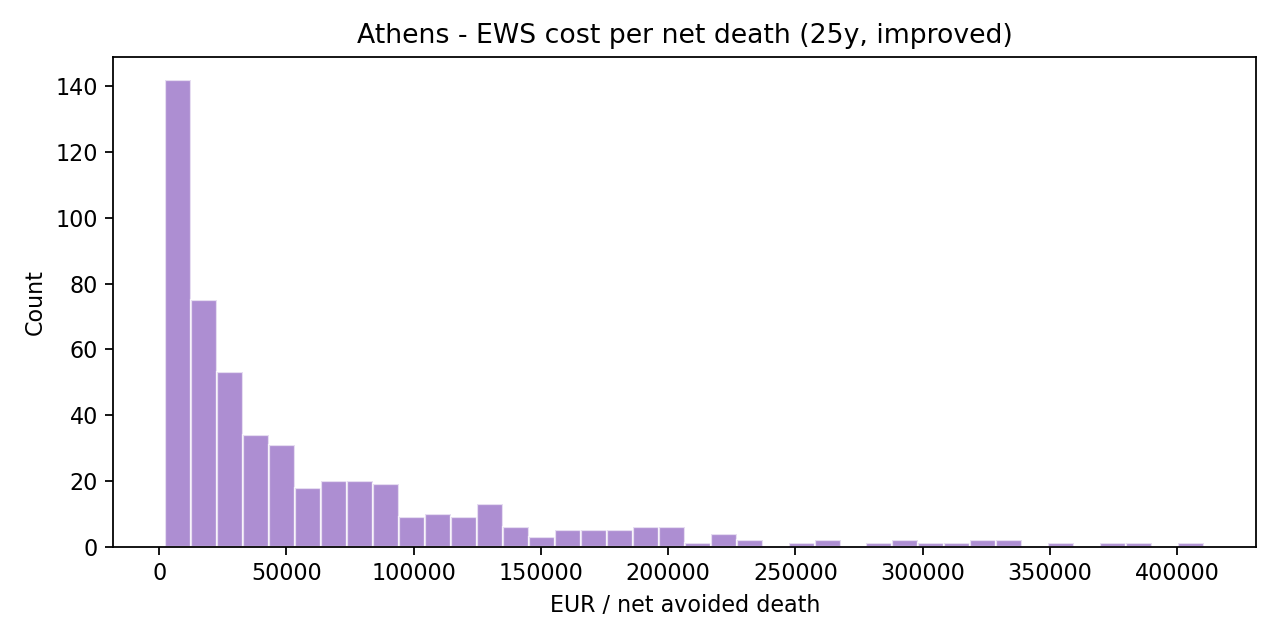

### unc_cdf_cba_ews_athens_improved_fast.png

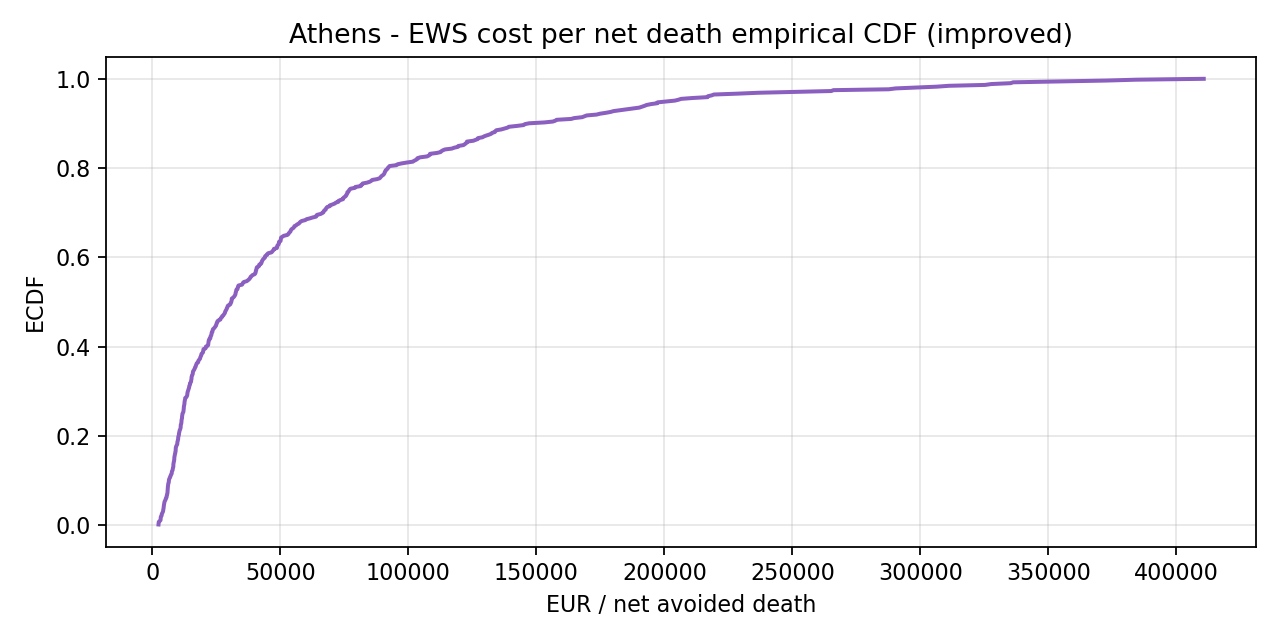

### sens_tornado_cba_ews_athens_improved_fast.png

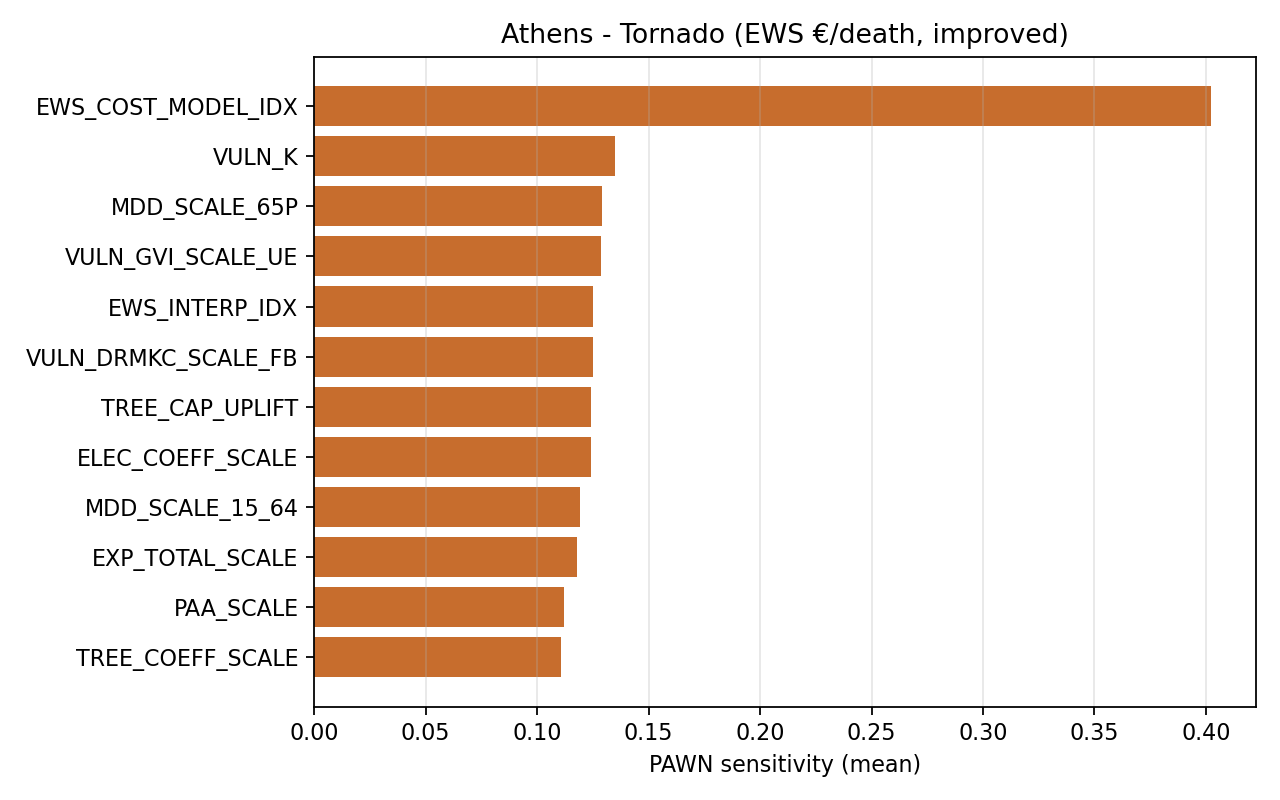

### unc_freq_curve_athens_improved_fast.png

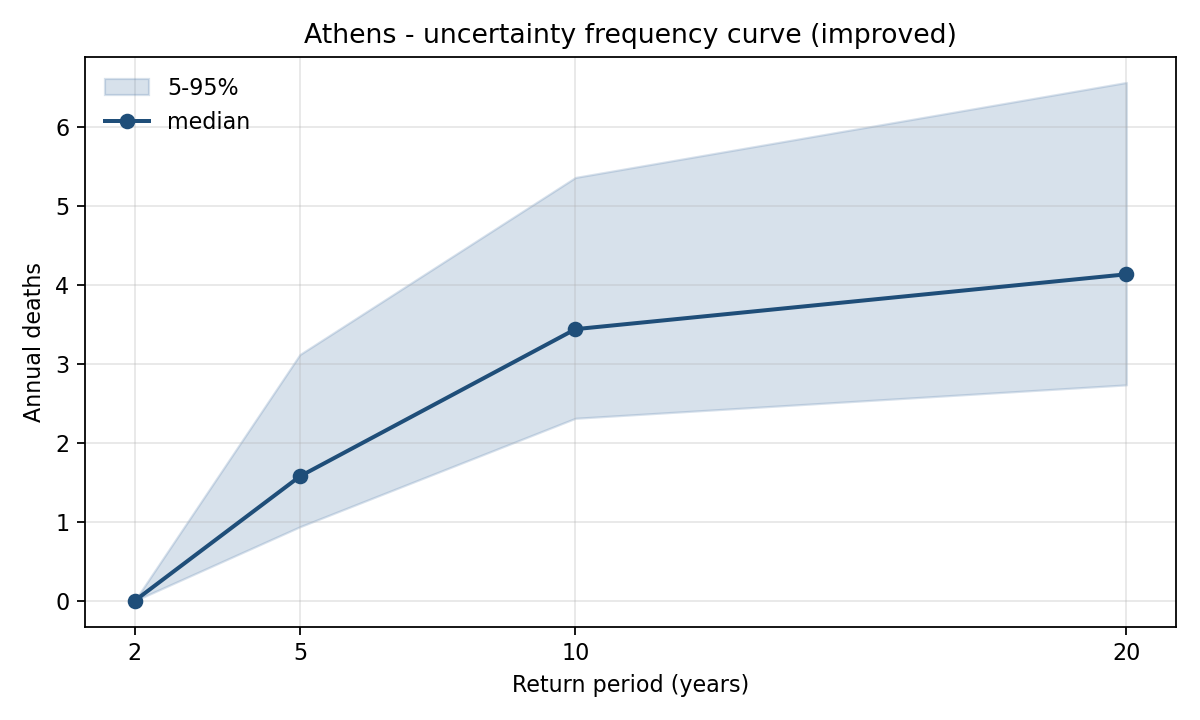

### unc_distribution_vuln_svi_mean_athens_improved_fast.png

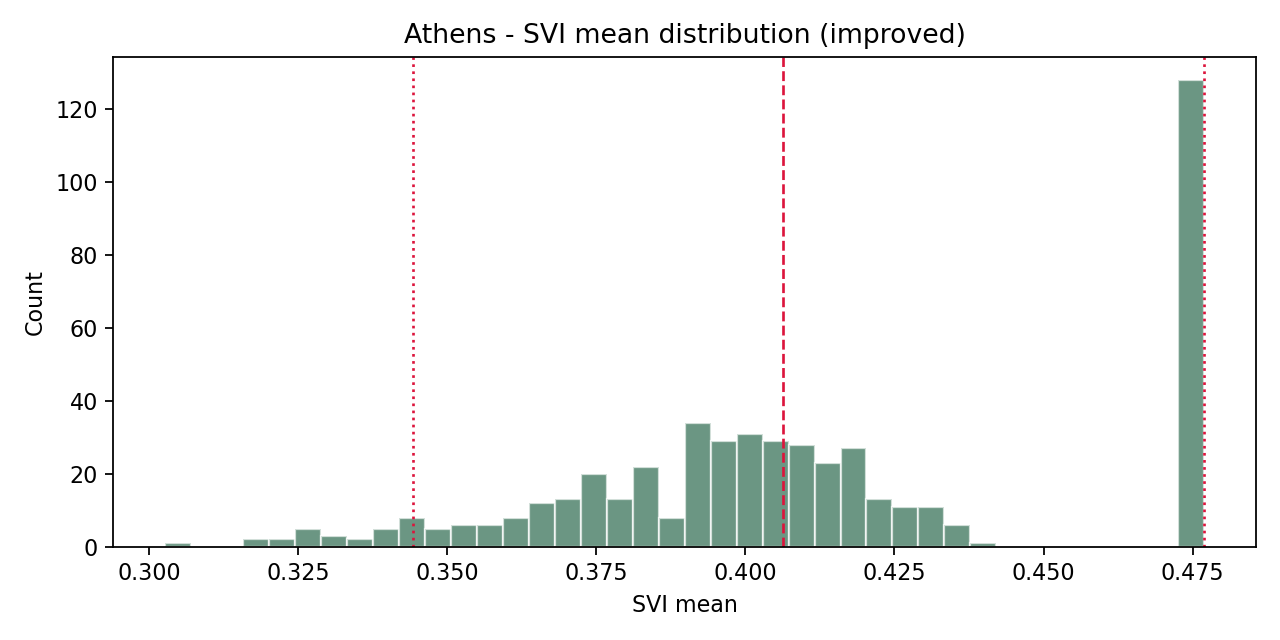

### unc_distribution_vuln_2050_svi_mean_athens_improved_fast.png

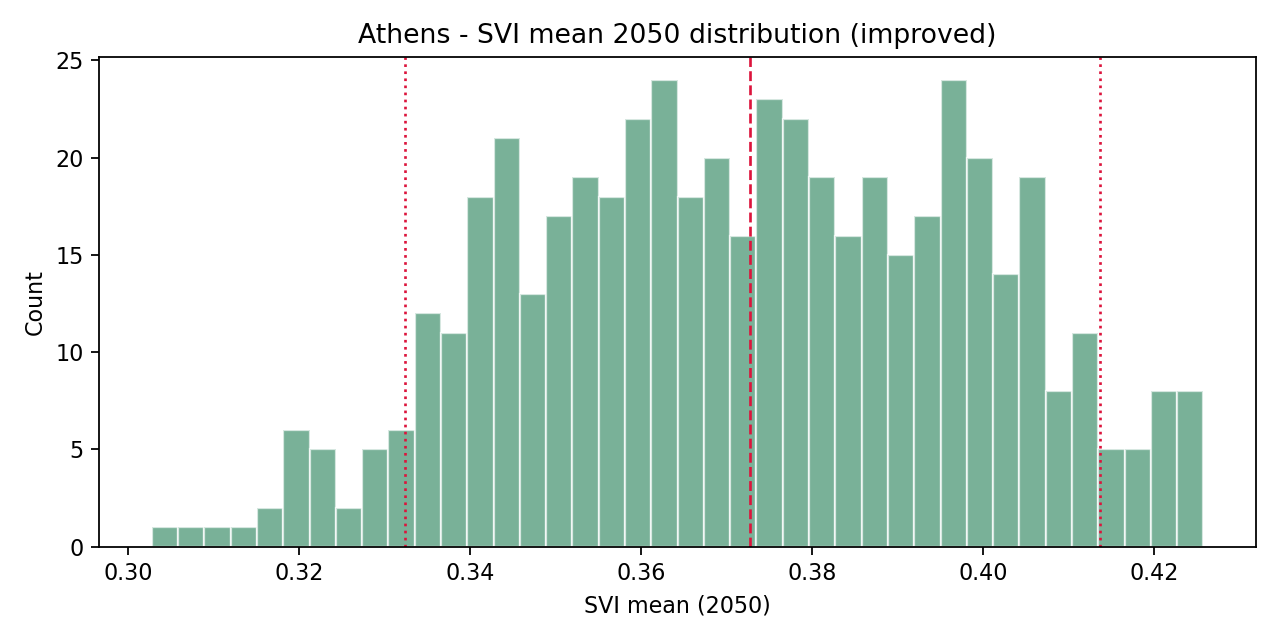

### sens_tornado_vuln_svi_gap_athens_improved_fast.png

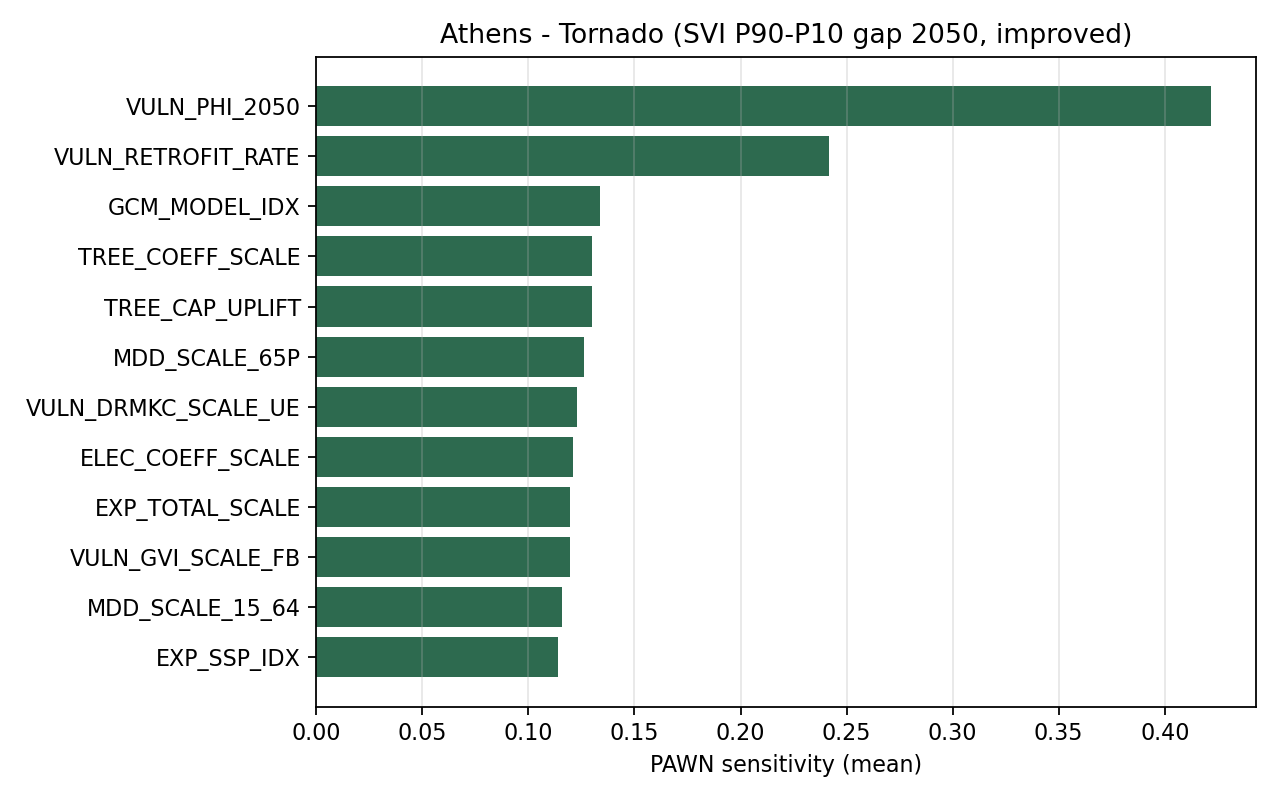

### sens_tornado_vuln_svi_mean_athens_improved_fast.png

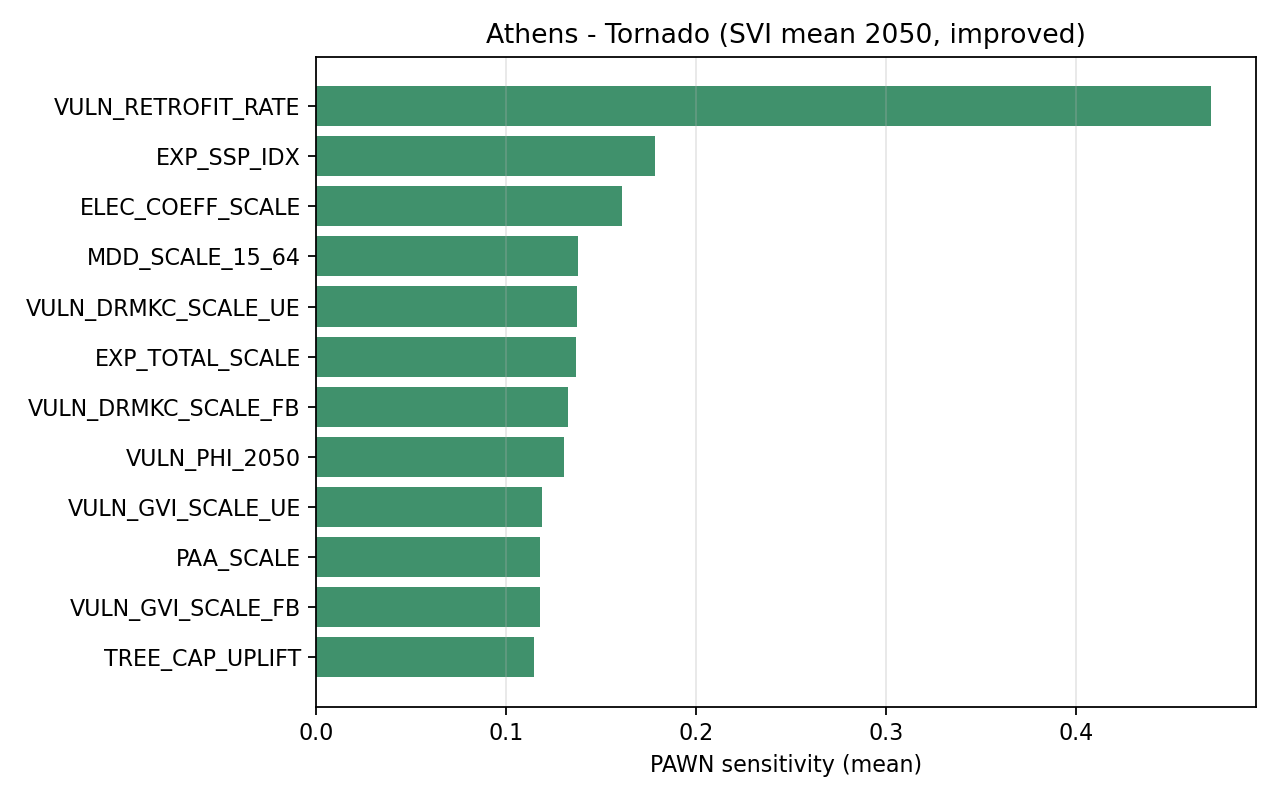

Generated headline figures displayed: 11

In [7]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

display(Markdown('## Masselot-main NB09 output paths'))
for _k, _v in sorted(paths.items()):
    display(Markdown(f'- {_k}: {_v}'))

samples = pd.read_csv(paths['samples'])
display(Markdown('## Headline sample IF-family counts'))
if 'if_family' in samples.columns:
    display(samples['if_family'].value_counts().rename_axis('if_family').to_frame('n'))

fig_dir = Path(paths['samples']).parent
fig_order = [
    'unc_distribution_aai_agg_athens_improved_fast.png',
    'unc_cdf_aai_agg_athens_improved_fast.png',
    'sens_tornado_aai_agg_athens_improved_fast.png',
    'unc_distribution_cba_ews_athens_improved_fast.png',
    'unc_cdf_cba_ews_athens_improved_fast.png',
    'sens_tornado_cba_ews_athens_improved_fast.png',
    'unc_freq_curve_athens_improved_fast.png',
    'unc_distribution_vuln_svi_mean_athens_improved_fast.png',
    'unc_distribution_vuln_2050_svi_mean_athens_improved_fast.png',
    'sens_tornado_vuln_svi_gap_athens_improved_fast.png',
    'sens_tornado_vuln_svi_mean_athens_improved_fast.png',
]
display(Markdown('## Generated headline NB09 figures'))
shown = 0
for fig_name in fig_order:
    fig_path = fig_dir / fig_name
    if fig_path.exists():
        display(Markdown(f'### {fig_name}'))
        display(Image(filename=str(fig_path)))
        shown += 1
display(Markdown(f'Generated headline figures displayed: {shown}'))